In [ ]:
# Importação das bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.cluster import KMeans

print("Todas as bibliotecas foram carregadas com sucesso!")

In [2]:
# Configuração visual padrão para os gráficos
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)

print("Estilo dos gráficos configurado!")

Estilo dos gráficos configurado!


In [3]:
# Criando a tabela de bairros e coordenadas (Mapa Base)
dados_bairros = {
    'bairro': ['Restaurante', 'Centro', 'Bairro A', 'Bairro B', 'Bairro C', 'Bairro D', 'Bairro E', 'Bairro F'],
    'pos_x': [0, 1, 1, 4, 5, 4, 0, -3],
    'pos_y': [0, 1, 4, 5, 1, -3, -4, -3],
    'tipo': ['Sede', 'Ponto', 'Ponto', 'Ponto', 'Ponto', 'Ponto', 'Ponto', 'Ponto']
}

# Convertendo o dicionário em uma Tabela Pandas (DataFrame)
df_bairros = pd.DataFrame(dados_bairros)

# Exibindo a tabela na tela
print("--- TABELA DE BAIRROS DA CIDADE ---")
df_bairros

--- TABELA DE BAIRROS DA CIDADE ---


,bairro,pos_x,pos_y,tipo
0,Restaurante,0,0,Sede
1,Centro,1,1,Ponto
2,Bairro A,1,4,Ponto
3,Bairro B,4,5,Ponto
4,Bairro C,5,1,Ponto
5,Bairro D,4,-3,Ponto
6,Bairro E,0,-4,Ponto
7,Bairro F,-3,-3,Ponto


In [4]:
# Criando a tabela de pedidos simulados para a hora do pico
dados_pedidos = {
    'id_pedido': [101, 102, 103, 104, 105, 106],
    'cliente': ['Ana', 'Bruno', 'Carla', 'Diego', 'Elena', 'Fábio'],
    'bairro_destino': ['Bairro A', 'Bairro B', 'Bairro C', 'Bairro D', 'Bairro E', 'Bairro F'],
    'valor_refeicao': [45.0, 32.5, 88.0, 54.0, 29.9, 61.0]
}

# Convertendo em Tabela Pandas
df_pedidos = pd.DataFrame(dados_pedidos)

# Exibindo a tabela na tela
print("--- PEDIDOS PENDENTES (HORÁRIO DE PICO) ---")
df_pedidos

--- PEDIDOS PENDENTES (HORÁRIO DE PICO) ---


,id_pedido,cliente,bairro_destino,valor_refeicao
0,101,Ana,Bairro A,45.0
1,102,Bruno,Bairro B,32.5
2,103,Carla,Bairro C,88.0
3,104,Diego,Bairro D,54.0
4,105,Elena,Bairro E,29.9
5,106,Fábio,Bairro F,61.0


In [5]:
# Importando a função para calcular distância geométrica simples (Euclidiana)
import math

# 1. Criando um grafo não-direcionado com NetworkX
G = nx.Graph()

# 2. Adicionando os nós (bairros) com suas posições (X, Y)
for idx, row in df_bairros.iterrows():
    G.add_node(row['bairro'], pos=(row['pos_x'], row['pos_y']))

# 3. Definindo as conexões (ruas) entre os bairros da nossa cidade fictícia
conexoes = [
    ('Restaurante', 'Centro'),
    ('Centro', 'Bairro A'),
    ('Centro', 'Bairro E'),
    ('Centro', 'Bairro F'),
    ('Bairro A', 'Bairro B'),
    ('Bairro B', 'Bairro C'),
    ('Bairro C', 'Bairro D'),
    ('Bairro D', 'Bairro E'),
    ('Bairro E', 'Bairro F'),
    ('Bairro F', 'Bairro A')
]

# 4. Adicionando as arestas (ruas) e calculando o peso (distância em km)
for origem, destino in conexoes:
    pos_origem = G.nodes[origem]['pos']
    pos_destino = G.nodes[destino]['pos']

    # Cálculo da distância em linha reta (distância euclidiana)
    distancia = math.sqrt((pos_destino[0] - pos_origem[0])**2 + (pos_destino[1] - pos_origem[1])**2)
    distancia_km = round(distancia, 2) # arredondando para 2 casas decimais

    # Adiciona a rua com o peso (distância)
    G.add_edge(origem, destino, weight=distancia_km)

print(f"Grafo criado com sucesso! Possui {G.number_of_nodes()} bairros e {G.number_of_edges()} conexões de ruas.")

Grafo criado com sucesso! Possui 8 bairros e 10 conexões de ruas.


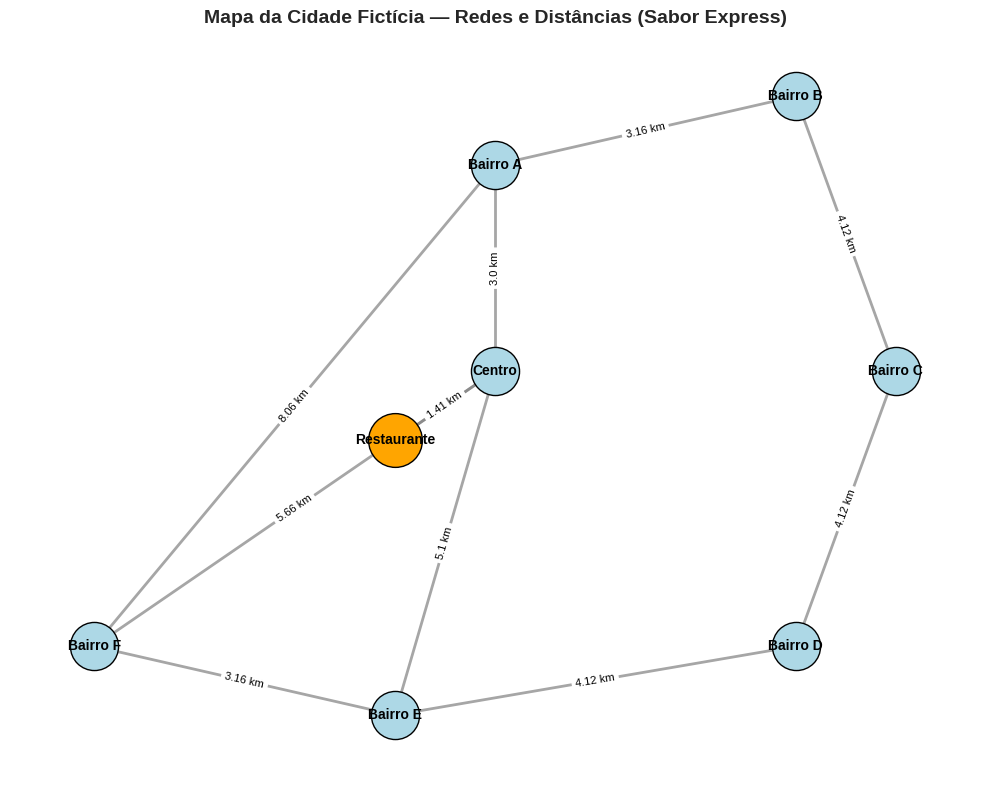

In [6]:
# Criando a figura do gráfico
plt.figure(figsize=(10, 8))

# Extraindo as posições (X, Y) de cada bairro registradas no Grafo
pos = nx.get_node_attributes(G, 'pos')

# Desenhando os bairros (nós) e as ruas (arestas)
nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='lightblue', edgecolors='black')
nx.draw_networkx_edges(G, pos, width=2, alpha=0.7, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_family='sans-serif')

# Extraindo os pesos (distâncias em km) de cada rua
pesos_arestas = nx.get_edge_attributes(G, 'weight')

# Formatando o texto dos pesos para exibir 'X km'
rotulos_arestas = {aresta: f"{peso} km" for aresta, peso in pesos_arestas.items()}

# Desenhando os rótulos de distância sobre as ruas
nx.draw_networkx_edge_labels(G, pos, edge_labels=rotulos_arestas, font_size=8)

# Destaque visual especial para a sede do Restaurante
nx.draw_networkx_nodes(G, pos, nodelist=['Restaurante'], node_size=1500, node_color='orange', edgecolors='black')

# Título e ajustes de exibição
plt.title("Mapa da Cidade Fictícia — Redes e Distâncias (Sabor Express)", fontsize=14, fontweight='bold')
plt.axis('off') # Remove os eixos numerados para parecer um mapa real
plt.tight_layout()

# Exibindo o gráfico na tela do Colab
plt.show()

In [7]:
# 1. Função de Heurística (Estimativa em linha reta entre o bairro atual e o destino final)
def heuristica_euclidiana(no_atual, no_destino):
    pos_atual = G.nodes[no_atual]['pos']
    pos_destino = G.nodes[no_destino]['pos']
    # Distância em linha reta no plano cartesiano
    return math.sqrt((pos_destino[0] - pos_atual[0])**2 + (pos_destino[1] - pos_atual[1])**2)

# 2. Função para encontrar o menor caminho entre dois pontos usando o algoritmo A*
def calcular_menor_caminho_astar(grafo, origem, destino):
    # O NetworkX possui uma implementação otimizada do algoritmo A*
    caminho = nx.astar_path(
        grafo,
        source=origem,
        target=destino,
        heuristic=heuristica_euclidiana,
        weight='weight'
    )

    # Calculando a distância total percorrida no caminho encontrado
    distancia_total = nx.astar_path_length(
        grafo,
        source=origem,
        target=destino,
        heuristic=heuristica_euclidiana,
        weight='weight'
    )

    return caminho, round(distancia_total, 2)

print("Algoritmo A* implementado e pronto para uso!")

Algoritmo A* implementado e pronto para uso!


In [8]:
# Definindo a origem e o destino do teste
ponto_partida = 'Restaurante'
ponto_chegada = 'Bairro C'

# Executando nossa função A*
rota_teste, distancia_teste = calcular_menor_caminho_astar(G, ponto_partida, ponto_chegada)

# Exibindo os resultados do teste
print("--- TESTE DE ROTA COM O ALGORITMO A* ---")
print(f"Saindo de: {ponto_partida}")
print(f"Indo para: {ponto_chegada}")
print(f"Caminho encontrado: {' -> '.join(rota_teste)}")
print(f"Distância total: {distancia_teste} km")

--- TESTE DE ROTA COM O ALGORITMO A* ---
Saindo de: Restaurante
Indo para: Bairro C
Caminho encontrado: Restaurante -> Centro -> Bairro A -> Bairro B -> Bairro C
Distância total: 11.69 km


In [9]:
# 1. Cruzando os pedidos com a tabela de bairros para obter as coordenadas (X, Y) de cada entrega
df_entregas_coords = pd.merge(df_pedidos, df_bairros, left_on='bairro_destino', right_on='bairro')

# 2. Extraindo apenas a matriz de coordenadas (X, Y) para o K-Means analisar
X_coordenadas = df_entregas_coords[['pos_x', 'pos_y']].values

# 3. Definindo a quantidade de entregadores (K = 2 grupos)
num_entregadores = 2

# 4. Criando e treinando o modelo K-Means
kmeans = KMeans(n_clusters=num_entregadores, random_state=42, n_init=10)
df_entregas_coords['cluster'] = kmeans.fit_predict(X_coordenadas)

# 5. Exibindo os pedidos agrupados por entregador/zona
print("--- ENTREGAS AGRUPADAS POR ZONA (K-MEANS) ---")
df_entregas_coords[['id_pedido', 'cliente', 'bairro_destino', 'pos_x', 'pos_y', 'cluster']]

--- ENTREGAS AGRUPADAS POR ZONA (K-MEANS) ---


,id_pedido,cliente,bairro_destino,pos_x,pos_y,cluster
0,101,Ana,Bairro A,1,4,1
1,102,Bruno,Bairro B,4,5,1
2,103,Carla,Bairro C,5,1,1
3,104,Diego,Bairro D,4,-3,0
4,105,Elena,Bairro E,0,-4,0
5,106,Fábio,Bairro F,-3,-3,0


In [10]:
# Dicionário para armazenar as rotas e distâncias de cada entregador
rotas_entregadores = {}

# Percorrendo cada cluster (Entregador 0 e Entregador 1)
for cluster_id in range(num_entregadores):
    # Filtrando as entregas que pertencem a este cluster
    entregas_cluster = df_entregas_coords[df_entregas_coords['cluster'] == cluster_id]['bairro_destino'].tolist()

    # O itinerário começa na sede do Restaurante
    ponto_atual = 'Restaurante'
    caminho_completo = [ponto_atual]
    distancia_total_cluster = 0.0

    # Otimizando a ordem de visita das entregas dentro do cluster
    pontos_pendentes = entregas_cluster.copy()

    while pontos_pendentes:
        melhor_proximo = None
        menor_dist = float('inf')
        melhor_trecho = []

        # Encontra a entrega mais próxima a partir do ponto atual usando A*
        for destino in pontos_pendentes:
            trecho, dist = calcular_menor_caminho_astar(G, ponto_atual, destino)
            if dist < menor_dist:
                menor_dist = dist
                melhor_proximo = destino
                melhor_trecho = trecho

        # Atualiza a rota acumulada e a distância total
        caminho_completo.extend(melhor_trecho[1:]) # ignora a origem repetida do trecho
        distancia_total_cluster += menor_dist
        ponto_atual = melhor_proximo
        pontos_pendentes.remove(melhor_proximo)

    # Retorno à sede do Restaurante após concluir as entregas do grupo
    trecho_retorno, dist_retorno = calcular_menor_caminho_astar(G, ponto_atual, 'Restaurante')
    caminho_completo.extend(trecho_retorno[1:])
    distancia_total_cluster += dist_retorno

    # Armazena os dados processados do entregador
    rotas_entregadores[f"Entregador {cluster_id + 1}"] = {
        'rota': caminho_completo,
        'distancia_km': round(distancia_total_cluster, 2)
    }

# Exibindo os resultados das rotas otimizadas na tela
print("--- ROTAS OTIMIZADAS DOS ENTREGADORES (K-MEANS + A*) ---")
for entregador, dados in rotas_entregadores.items():
    print(f"\n{entregador}:")
    print(f"Rota percorrida: {' -> '.join(dados['rota'])}")
    print(f"Distância total: {dados['distancia_km']} km")

--- ROTAS OTIMIZADAS DOS ENTREGADORES (K-MEANS + A*) ---

Entregador 1:
Rota percorrida: Restaurante -> Centro -> Bairro E -> Bairro F -> Bairro E -> Bairro D -> Bairro E -> Centro -> Restaurante
Distância total: 27.58 km

Entregador 2:
Rota percorrida: Restaurante -> Centro -> Bairro A -> Bairro B -> Bairro C -> Bairro B -> Bairro A -> Centro -> Restaurante
Distância total: 23.38 km


In [12]:
# 1. Calculando o tempo individual de cada entregador (em minutos)
dist_e1 = rotas_entregadores['Entregador 1']['distancia_km']
dist_e2 = rotas_entregadores['Entregador 2']['distancia_km']

tempo_e1_min = round((dist_e1 / velocidade_media) * 60, 1)
tempo_e2_min = round((dist_e2 / velocidade_media) * 60, 1)

# O tempo total para finalizar TODAS as entregas da cidade é o tempo do entregador que demora mais
tempo_max_ia_min = max(tempo_e1_min, tempo_e2_min)

# Média de distância percorrida por entregador
dist_media_por_entregador = round(distancia_ia / num_entregadores, 2)

# Economia no tempo de atendimento final da frota
economia_tempo_min = round(tempo_manual_min - tempo_max_ia_min, 1)
porcentagem_reducao_tempo = round(((tempo_manual_min - tempo_max_ia_min) / tempo_manual_min) * 100, 1)

# Tabela comparativa reestruturada
df_comparativo = pd.DataFrame({
    'Métrica de Desempenho': [
        'Número de Entregadores',
        'Distância Total da Frota (km)',
        'Distância Média por Entregador (km)',
        'Tempo de Espera Máximo do Cliente (min)',
        'Ganho de Tempo Total no Atendimento (%)'
    ],
    'Estratégia Manual (1 Moto)': [
        1,
        f"{distancia_manual} km",
        f"{distancia_manual} km",
        f"{tempo_manual_min} min",
        "-"
    ],
    'Estratégia IA (K-Means + A*)': [
        num_entregadores,
        f"{distancia_ia} km",
        f"{dist_media_por_entregador} km",
        f"{tempo_max_ia_min} min",
        f"{porcentagem_reducao_tempo}%"
    ]
})

print("--- RESULTADOS MENSURÁVEIS DA SOLUÇÃO (Ajustados) ---")
df_comparativo

--- RESULTADOS MENSURÁVEIS DA SOLUÇÃO (Ajustados) ---


,Métrica de Desempenho,Estratégia Manual (1 Moto),Estratégia IA (K-Means + A*)
0,Número de Entregadores,1,2
1,Distância Total da Frota (km),30.16 km,50.96 km
2,Distância Média por Entregador (km),30.16 km,25.48 km
3,Tempo de Espera Máximo do Cliente (min),60.3 min,55.2 min
4,Ganho de Tempo Total no Atendimento (%),-,8.5%


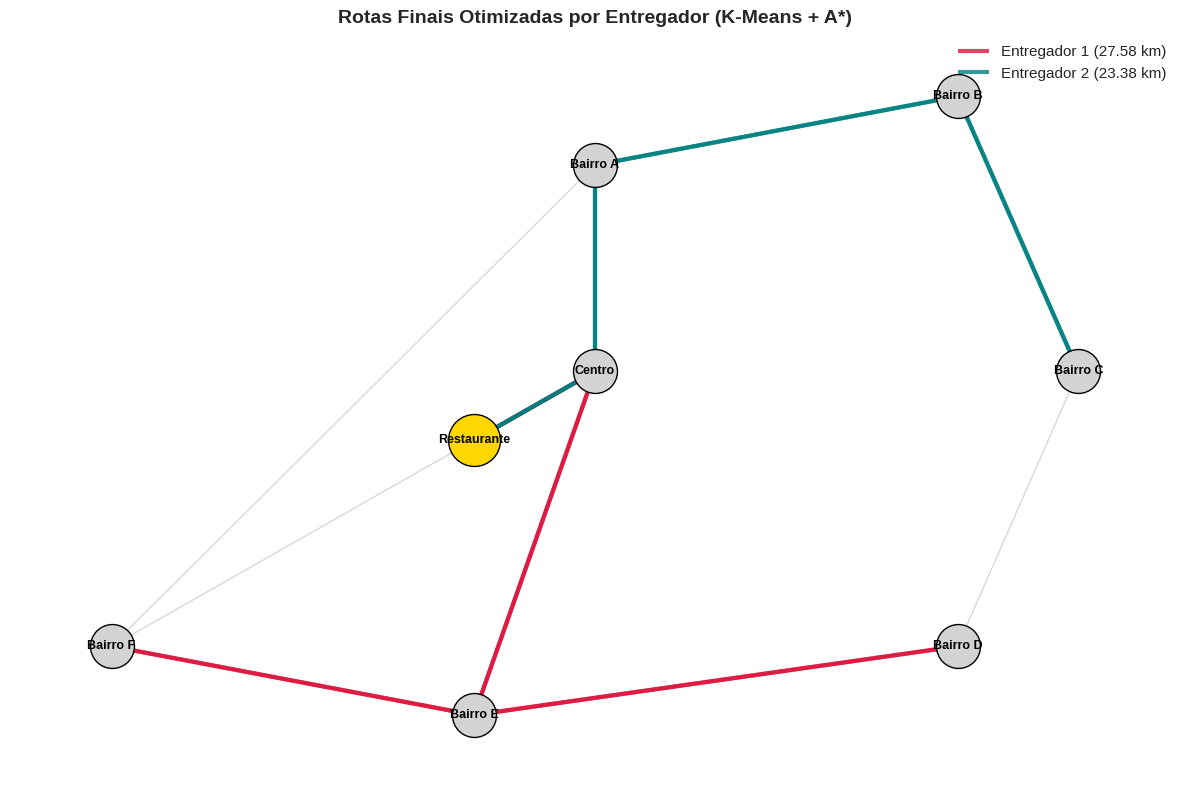

In [13]:
# Criando a figura para o mapa das rotas
plt.figure(figsize=(12, 8))

# Recuperando as posições (X, Y) dos bairros no Grafo
pos = nx.get_node_attributes(G, 'pos')

# 1. Desenhando a malha base da cidade em cinza claro
nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='lightgray', edgecolors='black')
nx.draw_networkx_edges(G, pos, width=1, alpha=0.3, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Destaque especial para a sede do Restaurante
nx.draw_networkx_nodes(G, pos, nodelist=['Restaurante'], node_size=1400, node_color='gold', edgecolors='black')

# Cores para cada entregador/cluster
cores_entregadores = ['crimson', 'teal']

# 2. Desenhando as rotas percorrida por cada entregador
for idx, (entregador, dados) in enumerate(rotas_entregadores.items()):
    rota = dados['rota']
    cor = cores_entregadores[idx % len(cores_entregadores)]

    # Montando os pares de conexões percorridos na rota (origem, destino)
    arestas_rota = [(rota[i], rota[i+1]) for i in range(len(rota)-1)]

    # Desenhando as linhas da rota com destaque de cor
    nx.draw_networkx_edges(
        G, pos,
        edgelist=arestas_rota,
        width=3,
        edge_color=cor,
        style='solid',
        alpha=0.8,
        label=f"{entregador} ({dados['distancia_km']} km)"
    )

# Título e Legendas
plt.title("Rotas Finais Otimizadas por Entregador (K-Means + A*)", fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.axis('off')
plt.tight_layout()

# Salvando a imagem no ambiente do Colab para usarmos no GitHub depois
plt.savefig('rotas_finais_otimizadas.png', dpi=300, bbox_inches='tight')

# Exibindo na tela
plt.show()

In [14]:
# Importando o módulo de arquivos do Google Colab para download automático
from google.colab import files

# 1. Salvação das tabelas em formato CSV na pasta do Colab
df_bairros.to_csv('bairros_coordenadas.csv', index=False)
df_pedidos.to_csv('pedidos_entregas.csv', index=False)
df_comparativo.to_csv('metricas_comparativas.csv', index=False)

print("Arquivos CSV salvos com sucesso! Baixando os arquivos e imagens...")

# 2. Fazendo o download dos arquivos para a sua máquina
files.download('bairros_coordenadas.csv')
files.download('pedidos_entregas.csv')
files.download('metricas_comparativas.csv')
files.download('rotas_finais_otimizadas.png')

Arquivos CSV salvos com sucesso! Baixando os arquivos e imagens...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>